In [1]:
import torch
from torch import nn
import torchvision
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
from torchvision.transforms import ToTensor


In [2]:
train_dataset = torchvision.datasets.MNIST(root='./data', 
                                           train=True, 
                                           download=True,
                                           transform=ToTensor())

In [3]:
test_dataset = torchvision.datasets.MNIST(root='./data', 
                                          train=False, 
                                          download=True, 
                                          transform=ToTensor())

In [4]:
train_dataset

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [5]:
test_dataset

Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: ToTensor()

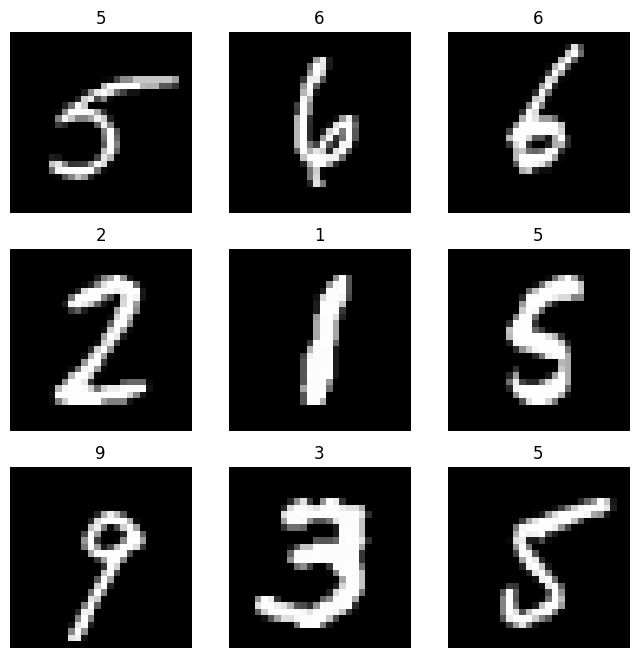

In [6]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_dataset), size=(1,)).item()
    img, label = train_dataset[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()


# Implement CNN model for MNIST

In [7]:
m = nn.Conv2d(1, 1, 2, stride=2, dilation=2)

In [8]:
m.weight = nn.Parameter(torch.tensor([[[[0.0, 1.0], [1.0, 0.0]]]]))
m.bias = nn.Parameter(torch.tensor([1.0]))

In [10]:
m.state_dict()

OrderedDict([('weight',
              tensor([[[[0., 1.],
                        [1., 0.]]]])),
             ('bias', tensor([1.]))])

In [12]:
input = torch.randint(high=3, low=-3, size=(1, 1, 10, 10)).float()
input

tensor([[[[-1.,  2., -2., -1., -1.,  0.,  2., -2.,  0.,  2.],
          [-3., -2., -1., -1., -1., -1., -2.,  1., -3.,  1.],
          [-1.,  1.,  0., -2., -2.,  2.,  0.,  1., -2., -3.],
          [-3.,  1.,  1.,  1.,  2., -1.,  0., -2.,  2., -1.],
          [-1., -1., -3.,  0.,  0.,  0.,  0., -3., -3., -2.],
          [ 1.,  0., -2.,  1., -2.,  1.,  1.,  1.,  1., -3.],
          [-3.,  0., -2.,  1.,  1., -3.,  2., -3., -3.,  1.],
          [ 0., -1., -2., -1., -2.,  2.,  2.,  1.,  2., -3.],
          [ 2., -3.,  0., -1., -1., -3., -2.,  2.,  1., -3.],
          [-3.,  2., -2., -3., -1.,  0., -3., -3., -1., -3.]]]])

In [13]:
m(input)

tensor([[[[-2.,  0.,  1.,  1.],
          [ 0., -4.,  1., -1.],
          [-5., -1.,  2.,  0.],
          [ 1.,  2.,  2., -4.]]]], grad_fn=<ConvolutionBackward0>)

In [14]:
class AlexNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_layer1 = nn.Conv2d(1, 6, 5, stride=1, padding=2) 
        self.avg_pool1 = nn.AvgPool2d(2, stride=2)
        self.conv_layer2 = nn.Conv2d(6, 16, 5, stride=1)
        self.avg_pool2 = nn.AvgPool2d(2, stride=2)
        self.fc1 = nn.Linear(400, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
        
    def forward(self, x):
        '''
            x dim is (N, 1, 28, 28)
        '''
        bs = x.shape[0]
        x = self.conv_layer1(x) # (N, 6, 28, 28)
        x = self.avg_pool1(x) # (N, 6, 14, 14)
        x = self.conv_layer2(x) # (N, 16, 10, 10)
        x = self.avg_pool2(x) # (N, 16, 5, 5)
        x = x.reshape(bs, -1) # (N, 256)
        x = self.fc1(x)
        x = nn.functional.relu(x)
        x = self.fc2(x)
        x = nn.functional.relu(x)
        x = self.fc3(x)
        
        return x

    def loss(self, x, y):
        y_logits = self.forward(x)
        return nn.functional.cross_entropy(y_logits, y)

In [17]:
n_epoch = 5
batch_size = 60
rn = AlexNet()
opt = torch.optim.Adam(rn.parameters(), lr=3e-4)
rn.train()


for i in range(n_epoch):
    print(f"----------------epoch {i}----------------------")
    print("Shuffling data")
    train_loader = DataLoader(train_dataset, 
                      batch_size=batch_size, 
                      shuffle=True) # Shuffle the training data for better training

    for j, batch in enumerate(train_loader):
        opt.zero_grad()
        loss = rn.loss(batch[0], batch[1])
        loss.backward()
        opt.step()
        if j % 100 == 0:
            print(loss)

----------------epoch 0----------------------
Shuffling data
tensor(2.3266, grad_fn=<NllLossBackward0>)
tensor(1.0119, grad_fn=<NllLossBackward0>)
tensor(0.7075, grad_fn=<NllLossBackward0>)
tensor(0.6446, grad_fn=<NllLossBackward0>)
tensor(0.2272, grad_fn=<NllLossBackward0>)
tensor(0.5428, grad_fn=<NllLossBackward0>)
tensor(0.3240, grad_fn=<NllLossBackward0>)
tensor(0.2792, grad_fn=<NllLossBackward0>)
tensor(0.3311, grad_fn=<NllLossBackward0>)
tensor(0.2849, grad_fn=<NllLossBackward0>)
----------------epoch 1----------------------
Shuffling data
tensor(0.3170, grad_fn=<NllLossBackward0>)
tensor(0.5224, grad_fn=<NllLossBackward0>)
tensor(0.4501, grad_fn=<NllLossBackward0>)
tensor(0.3061, grad_fn=<NllLossBackward0>)
tensor(0.1427, grad_fn=<NllLossBackward0>)
tensor(0.1924, grad_fn=<NllLossBackward0>)
tensor(0.2030, grad_fn=<NllLossBackward0>)
tensor(0.2307, grad_fn=<NllLossBackward0>)
tensor(0.2444, grad_fn=<NllLossBackward0>)
tensor(0.2148, grad_fn=<NllLossBackward0>)
----------------ep

In [18]:
def compute_accuracy(n_samples=100, random_seed=42, is_train=True):
    torch.manual_seed(random_seed)
    if is_train:
        sample_idx = torch.randint(len(train_dataset), size=(n_samples,))
        X = torch.stack([train_dataset[i][0] for i in sample_idx])
        y = torch.tensor([train_dataset[i][1] for i in sample_idx])
    else:
        sample_idx = torch.randint(len(test_dataset), size=(n_samples,))
        X = torch.stack([test_dataset[i][0] for i in sample_idx])
        y = torch.tensor([test_dataset[i][1] for i in sample_idx])

    y_pred = rn(X).argmax(dim=1).numpy()
    # plot wrong samples
    figure = plt.figure(figsize=(12, 12))
    cols, rows = 3, 3
    
    wrong_samples = sample_idx[(y_pred != y.numpy())].numpy()
    for i in range(1, min(10, len(wrong_samples)+1)):
        img, label = train_dataset[wrong_samples[i-1]]
        figure.add_subplot(rows, cols, i)
        plt.title(f"Sample {wrong_samples[i-1]}, Actual {label}, Predicted {y_pred[(y_pred != y.numpy())][i-1]}")
        plt.axis("off")
        plt.imshow(img.squeeze(), cmap="gray")
    plt.show()
    
    return (rn(X).argmax(dim=1) == y).float().mean()

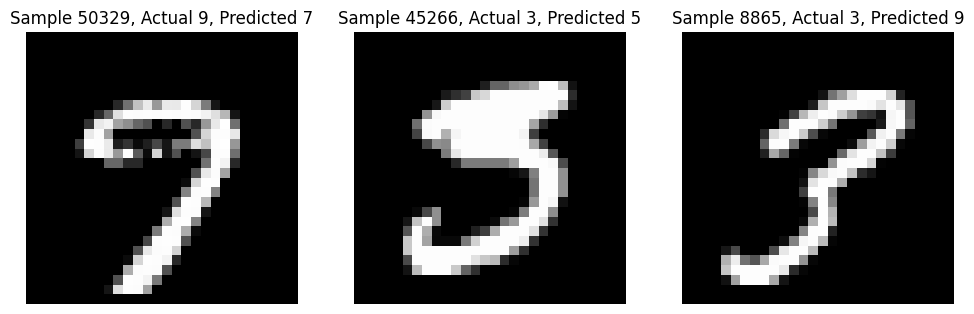

tensor(0.9700)

In [19]:
compute_accuracy(is_train=True, n_samples=100)


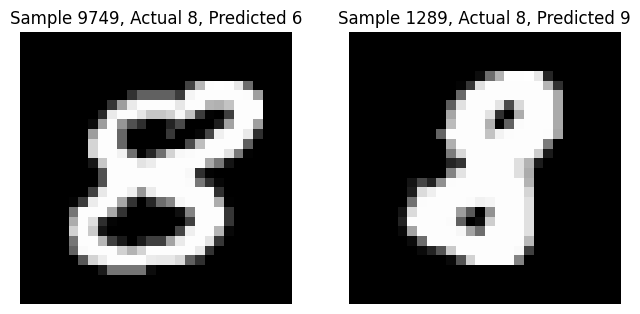

tensor(0.9800)

In [20]:
compute_accuracy(is_train=False, n_samples=100)